In [ ]:
# Kaggle install and setup
!pip install kaggle -q

from google.colab import files
files.upload()  # kaggle.json upload 

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print(" Kaggle ready!")

Saving kaggle.json to kaggle.json
✅ Kaggle ready!


In [ ]:
# HAM10000 download
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000
print("Download complete!")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:00<00:00, 92.5MB/s]

✅ Download complete!


In [ ]:
#Folder Structure:
import os, shutil, pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/ham10000/HAM10000_metadata.csv')

selected = {
    'mel':   'melanoma',
    'akiec': 'keratosis',
    'nv':    'nevus',
    'bkl':   'benign'
}
df = df[df['dx'].isin(selected.keys())]
df['label'] = df['dx'].map(selected)
df = df.reset_index(drop=True)  # ← index fix

img_dir1 = '/content/ham10000/HAM10000_images_part_1/'
img_dir2 = '/content/ham10000/HAM10000_images_part_2/'

def find_image(image_id):
    for folder in [img_dir1, img_dir2]:
        path = os.path.join(folder, image_id + '.jpg')
        if os.path.exists(path):
            return path
    return None

df['filepath'] = df['image_id'].apply(find_image)
df = df.dropna(subset=['filepath'])
df = df.reset_index(drop=True)  # ← index fix

# Use the train_test_split function from scikit-learn to divide your dataset into training and testing sets.
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

for split_name, split_df in [('train', train_df), ('test', test_df)]:
    for _, row in split_df.iterrows():
        dest = os.path.join('/content/dataset', split_name, row['label'])
        os.makedirs(dest, exist_ok=True)
        shutil.copy(row['filepath'], dest)

print("Dataset ready!")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

for split in ['train', 'test']:
    for cls in ['melanoma', 'keratosis', 'nevus', 'benign']:
        path = f'/content/dataset/{split}/{cls}'
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

✅ Dataset ready!
Train: 7395 | Test: 1849
train/melanoma: 890 images
train/keratosis: 262 images
train/nevus: 5364 images
train/benign: 879 images
test/melanoma: 223 images
test/keratosis: 65 images
test/nevus: 1341 images
test/benign: 220 images


In [ ]:
#Image Preprocessing:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 7395 images belonging to 4 classes.
Found 1849 images belonging to 4 classes.
Classes: {'benign': 0, 'keratosis': 1, 'melanoma': 2, 'nevus': 3}


In [ ]:
#MobileNetV2 Model Build
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze base

# Add Custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(4, activation='softmax')(x)  # 4 classes

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model ready!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Model Training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

# Moderate class weights (not balanced — gentle only)
class_weights = {
    0: 1.5,   # benign
    1: 4.0,   # keratosis (less images)
    2: 1.5,   # melanoma
    3: 0.5    # nevus (most images)
}
print("Class weights:", class_weights)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        '/content/detectderm_best_model.h5',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=callbacks
)

print(" Training complete!")
print(f"Best val_accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Class weights: {0: 1.5, 1: 4.0, 2: 1.5, 3: 0.5}
Epoch 1/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7422 - loss: 0.7120
Epoch 1: val_loss improved from None to 0.73717, saving model to /content/detectderm_best_model.h5



Epoch 1: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.7262 - loss: 0.7384 - val_accuracy: 0.6961 - val_loss: 0.7372
Epoch 2/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7282 - loss: 0.7181
Epoch 2: val_loss improved from 0.73717 to 0.65260, saving model to /content/detectderm_best_model.h5



Epoch 2: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.7291 - loss: 0.7355 - val_accuracy: 0.7334 - val_loss: 0.6526
Epoch 3/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7371 - loss: 0.7119
Epoch 3: val_loss improved from 0.65260 to 0.64902, saving model to /content/detectderm_best_model.h5



Epoch 3: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.7339 - loss: 0.7153 - val_accuracy: 0.7399 - val_loss: 0.6490
Epoch 4/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7419 - loss: 0.6824
Epoch 4: val_loss did not improve from 0.64902
232/232 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.7335 - loss: 0.7059 - val_accuracy: 0.7117 - val_loss: 0.7317
Epoch 5/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7428 - loss: 0.6993
Epoch 5: val_loss improved from 0.64902 to 0.64546, saving model to /content/detectderm_best_model.h5



Epoch 5: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.7393 - loss: 0.7176 - val_accuracy: 0.7507 - val_loss: 0.6455
Epoch 6/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7461 - loss: 0.7054
Epoch 6: val_loss did not improve from 0.64546
232/232 ━━━━━━━━━━━━━━━━━━━━ 480s 2s/step - accuracy: 0.7356 - loss: 0.7130 - val_accuracy: 0.7420 - val_loss: 0.6465
Epoch 7/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7415 - loss: 0.7041
Epoch 7: val_loss improved from 0.64546 to 0.63238, saving model to /content/detectderm_best_model.h5



Epoch 7: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.7435 - loss: 0.6971 - val_accuracy: 0.7458 - val_loss: 0.6324
Epoch 8/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7443 - loss: 0.6916
Epoch 8: val_loss did not improve from 0.63238
232/232 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - accuracy: 0.7462 - loss: 0.6765 - val_accuracy: 0.7052 - val_loss: 0.6942
Epoch 9/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7419 - loss: 0.7016
Epoch 9: val_loss improved from 0.63238 to 0.63151, saving model to /content/detectderm_best_model.h5



Epoch 9: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.7431 - loss: 0.7008 - val_accuracy: 0.7420 - val_loss: 0.6315
Epoch 10/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7424 - loss: 0.7078
Epoch 10: val_loss did not improve from 0.63151
232/232 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.7427 - loss: 0.6994 - val_accuracy: 0.7290 - val_loss: 0.6651
Epoch 11/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7469 - loss: 0.6756
Epoch 11: val_loss did not improve from 0.63151
232/232 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.7498 - loss: 0.6780 - val_accuracy: 0.6760 - val_loss: 0.7385
Epoch 12/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7461 - loss: 0.6975
Epoch 12: val_loss did not improve from 0.63151
232/232 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.7584 - loss: 0.6827 - val_accuracy: 0.6912 - val_loss: 0.7534
Epoch 13/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc


Epoch 13: finished saving model to /content/detectderm_best_model.h5
232/232 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.7532 - loss: 0.6664 - val_accuracy: 0.7593 - val_loss: 0.6088
Epoch 14/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7591 - loss: 0.6635
Epoch 14: val_loss did not improve from 0.60883
232/232 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.7525 - loss: 0.6711 - val_accuracy: 0.7215 - val_loss: 0.6797
Epoch 15/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7450 - loss: 0.6598
Epoch 15: val_loss did not improve from 0.60883
232/232 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.7513 - loss: 0.6654 - val_accuracy: 0.7085 - val_loss: 0.6918
Epoch 16/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7566 - loss: 0.6491
Epoch 16: val_loss did not improve from 0.60883
232/232 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.7556 - loss: 0.6574 - val_accuracy: 0.7231 - val_loss: 0.6701
Epoch 17/20
232/232 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - ac

In [ ]:
#Training Result
print(f"Best val_accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

Best val_accuracy: 75.93%
Best val_loss: 0.6088


In [ ]:
# Model Save
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy('/content/detectderm_best_model.h5',
            '/drive/MyDrive/detectderm_best_model.h5')
print("Model is Saved in Google Drive")

Mounted at /drive
Model Save in Google Drive


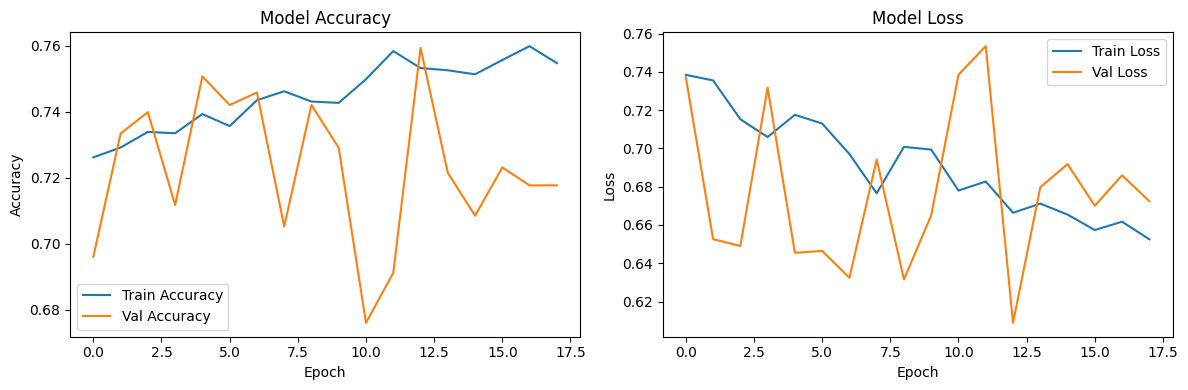

58/58 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step


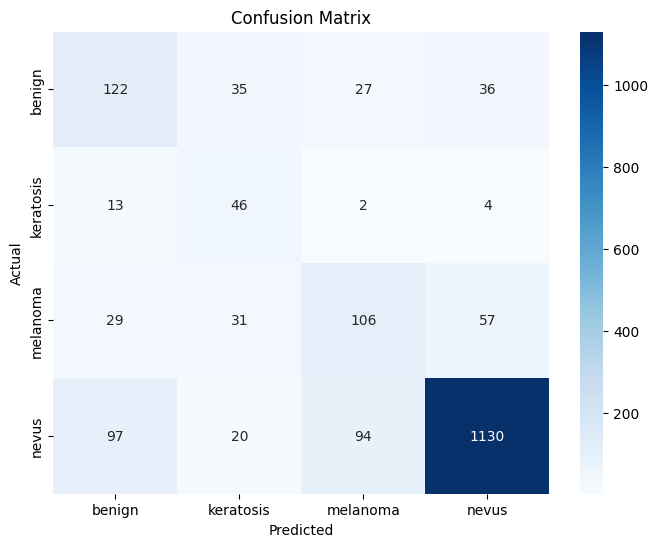


Classification Report:
              precision    recall  f1-score   support

      benign       0.47      0.55      0.51       220
   keratosis       0.35      0.71      0.47        65
    melanoma       0.46      0.48      0.47       223
       nevus       0.92      0.84      0.88      1341

    accuracy                           0.76      1849
   macro avg       0.55      0.65      0.58      1849
weighted avg       0.79      0.76      0.77      1849



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Accuracy & Loss Graph
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('/drive/MyDrive/training_graphs.png')
plt.show()

# Confusion Matrix
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/drive/MyDrive/confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [ ]:
from google.colab import files
files.download('/content/detectderm_best_model.h5')